In [151]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [152]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

In [153]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [154]:
from langchain_groq import ChatGroq

# LLM Initialization 
llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [155]:
# Defining tools for llm
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools.arxiv.tool import ArxivQueryRun

arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=4, doc_content_chars_max=2000)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)
arxiv.invoke("tell me about the demand of agentic ai engineers")

'Published: 2026-05-17\nTitle: Towards trustworthy agentic AI: a comprehensive survey of safety, robustness, privacy, and system security\nAuthors: Jinhu Qi, Muzhi Li, Jiahong Liu, Yuqin Shu, Dianzhi Yu, Shicheng Ma, Wenqian Cui, Yiyang Zhao, Yiyi Chen, Ruoxi Jiang, Irwin King, Zenglin Xu\nSummary: Agentic AI systems -- Large Language Models (LLMs) augmented with planning, tool use, memory, and long-horizon interactions -- can execute complex tasks autonomously, but their multi-step trajectories introduce new failure modes that challenge trustworthiness. This survey provides a focused examination of trustworthy agentic AI through two core dimensions that are critical for high-risk deployments: Safety and Robustness, and Privacy and System Security. For each dimension, we clarify key concepts, identify where risks emerge along the agent workflow, and summarize stage-targeted mitigation strategies. Other trustworthiness aspects (value alignment, transparency, fairness, and accountability

In [156]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [157]:
def multiply(a: int, b: int):
  """
    Summary: Multiply two integers
    Args: a: first integer, b: second integer
    Returns: Output result integer of the multiplication 
  """

  return a * b

def add(a: int, b: int):
  """
    Summary: Add two integers
    Args: a: first integer, b: second integer
    Returns: Output result integer of the addition 
  """

  return a + b

In [158]:
tools = [arxiv, tavily, add, multiply]

In [159]:
llm_with_tools = llm.bind_tools(tools=tools)

In [160]:
llm_with_tools.invoke("Tell me about the demand of agentic ai engineers in 2030")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dddh8qqeq', 'function': {'arguments': '{"query":"agentic ai engineers demand 2030"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 635, 'total_tokens': 660, 'completion_time': 0.068183415, 'completion_tokens_details': None, 'prompt_time': 0.042812685, 'prompt_tokens_details': None, 'queue_time': 0.193562626, 'total_time': 0.1109961}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecab3-5e4f-7d70-9463-06ad3cb7677a-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'agentic ai engineers demand 2030'}, 'id': 'dddh8qqeq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 635, 'output_tokens': 25, 'total_tokens': 660})

In [161]:
# Node Definition
def tool_calling_llm_chatbot(state: State):
  print('current state', state)
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [162]:
from langgraph.prebuilt import ToolNode, tools_condition

In [166]:
graph_builder = StateGraph(State)

# Adding nodes - Here we are creating only one node as we have only one
graph_builder.add_node('tool_calling_llm_chatbot', tool_calling_llm_chatbot)
graph_builder.add_node('tools', ToolNode(tools))

# Adding edges
graph_builder.add_edge(START, 'tool_calling_llm_chatbot')
graph_builder.add_conditional_edges(
  "tool_calling_llm_chatbot", 
  # so basically what does the tools_condition function do, it will check if the latest message (i.e. input) given to the llm is a tool call, then it will route to the tools node and how is it gonna know that the message is a tool call, well llm informs it by telling in the metadata that it is a tool call, and if the llm tells that the input given to the llm is not a tool call, then it will route to end after serving. 
  tools_condition
)
graph_builder.add_edge('tools', "tool_calling_llm_chatbot")

# Compiling the graph
graph = graph_builder.compile()


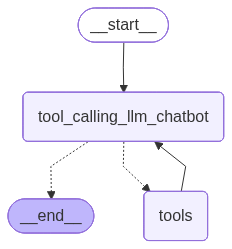

In [167]:
# Visualizing the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [170]:
response = graph.invoke({"messages": "what is mythos fable 5 and also multiply 12 with 24"})

print(response["messages"])

for res in response["messages"]:
  res.pretty_print()

current state {'messages': [HumanMessage(content='what is mythos fable 5 and also multiply 12 with 24', additional_kwargs={}, response_metadata={}, id='e7eab768-856d-40a3-8029-6779f719783d')]}
current state {'messages': [HumanMessage(content='what is mythos fable 5 and also multiply 12 with 24', additional_kwargs={}, response_metadata={}, id='e7eab768-856d-40a3-8029-6779f719783d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gkraw8m9p', 'function': {'arguments': '{"query":"mythos fable 5"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '124092bdc', 'function': {'arguments': '{"a":12,"b":24}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 637, 'total_tokens': 679, 'completion_time': 0.092887469, 'completion_tokens_details': None, 'prompt_time': 0.03424687, 'prompt_tokens_details': None, 'queue_time': 0.19339528, 'total_time': 0.127134339}, 'model_name': 'llama-3.3-70b-ver

### Adding Memory in LangGraph

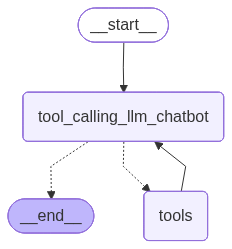

In [172]:
from langgraph.checkpoint.memory import MemorySaver

# Initializing the graph
graph_builder = StateGraph(State)

# Adding memory in my agent
memory = MemorySaver()

# Adding nodes - Here we are creating only one node as we have only one
graph_builder.add_node('tool_calling_llm_chatbot', tool_calling_llm_chatbot)
graph_builder.add_node('tools', ToolNode(tools))

# Adding edges
graph_builder.add_edge(START, 'tool_calling_llm_chatbot')
graph_builder.add_conditional_edges(
  "tool_calling_llm_chatbot", 
  # so basically what does the tools_condition function do, it will check if the latest message (i.e. input) given to the llm is a tool call, then it will route to the tools node and how is it gonna know that the message is a tool call, well llm informs it by telling in the metadata that it is a tool call, and if the llm tells that the input given to the llm is not a tool call, then it will route to end after serving. 
  tools_condition
)
graph_builder.add_edge('tools', "tool_calling_llm_chatbot")

# Compiling the graph
graph = graph_builder.compile(checkpointer=memory)


# Visualizing the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

config = {"configurable": {"thread_id": "1"}}


In [175]:
res = graph.invoke({"messages": "hey my name is ahmad"}, config=config)

response = res['messages'][-1].content

response

current state {'messages': [HumanMessage(content='hey my name is ahmad, how are you?', additional_kwargs={}, response_metadata={}, id='53bc40a1-53be-4097-a2b5-5dc85a3dddf0'), AIMessage(content="I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. It's nice to meet you, Ahmad. Is there something I can assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 632, 'total_tokens': 683, 'completion_time': 0.136768798, 'completion_tokens_details': None, 'prompt_time': 0.034247066, 'prompt_tokens_details': None, 'queue_time': 0.193291544, 'total_time': 0.171015864}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecac1-bfb3-7a43-8c5d-3751896625c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

"It's nice to meet you, Ahmad. Is there something I can help you with or would you like to chat?"

In [176]:
res = graph.invoke({"messages": "what is my name?"}, config=config)

response = res['messages'][-1].content

response

current state {'messages': [HumanMessage(content='hey my name is ahmad, how are you?', additional_kwargs={}, response_metadata={}, id='53bc40a1-53be-4097-a2b5-5dc85a3dddf0'), AIMessage(content="I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. It's nice to meet you, Ahmad. Is there something I can assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 632, 'total_tokens': 683, 'completion_time': 0.136768798, 'completion_tokens_details': None, 'prompt_time': 0.034247066, 'prompt_tokens_details': None, 'queue_time': 0.193291544, 'total_time': 0.171015864}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecac1-bfb3-7a43-8c5d-3751896625c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

'Your name is Ahmad.'

In [177]:
res = graph.invoke({"messages": "are you sure about that?"}, config=config)

response = res['messages'][-1].content

response

current state {'messages': [HumanMessage(content='hey my name is ahmad, how are you?', additional_kwargs={}, response_metadata={}, id='53bc40a1-53be-4097-a2b5-5dc85a3dddf0'), AIMessage(content="I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. It's nice to meet you, Ahmad. Is there something I can assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 632, 'total_tokens': 683, 'completion_time': 0.136768798, 'completion_tokens_details': None, 'prompt_time': 0.034247066, 'prompt_tokens_details': None, 'queue_time': 0.193291544, 'total_time': 0.171015864}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecac1-bfb3-7a43-8c5d-3751896625c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

'Yes, I am sure. You told me earlier that your name is Ahmad.'

In [178]:
res = graph.invoke({"messages": "good, you remembered it right"}, config=config)

response = res['messages'][-1].content

response

current state {'messages': [HumanMessage(content='hey my name is ahmad, how are you?', additional_kwargs={}, response_metadata={}, id='53bc40a1-53be-4097-a2b5-5dc85a3dddf0'), AIMessage(content="I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. It's nice to meet you, Ahmad. Is there something I can assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 632, 'total_tokens': 683, 'completion_time': 0.136768798, 'completion_tokens_details': None, 'prompt_time': 0.034247066, 'prompt_tokens_details': None, 'queue_time': 0.193291544, 'total_time': 0.171015864}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecac1-bfb3-7a43-8c5d-3751896625c9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

"I'm glad I could recall your name correctly, Ahmad. If you need anything or want to chat, feel free to ask me anytime."

### Streaming in LangGraph (stream, astream, values, updates)

In [179]:
def chatbot(state: State):
  return {"messages": [llm.invoke(state["messages"])]}

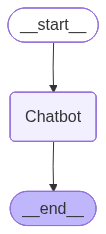

In [180]:
from IPython.display import display, Image

builder = StateGraph(State)

# Adding nodes
builder.add_node('Chatbot', chatbot)

# Adding edges
builder.add_edge(START, 'Chatbot')
builder.add_edge("Chatbot", END)

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": 2}}

for chunk in graph.stream({"messages": "Hi my name is Ahmad"}, config=config, stream_mode="updates"):
  print(chunk)

{'Chatbot': {'messages': [AIMessage(content="Hello Ahmad, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 40, 'total_tokens': 66, 'completion_time': 0.052241941, 'completion_tokens_details': None, 'prompt_time': 0.003687525, 'prompt_tokens_details': None, 'queue_time': 0.200688638, 'total_time': 0.055929466}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecad6-522b-7e61-acca-ecee50f6649e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 26, 'total_tokens': 66})]}}


In [184]:
config = {"configurable": {"thread_id": 3}}

for chunk in graph.stream({"messages": "Hi my name is Ahmad and I like playing cricket"}, config=config, stream_mode="values"):
  print(chunk)

{'messages': [HumanMessage(content='Hi my name is Ahmad and I like playing cricket', additional_kwargs={}, response_metadata={}, id='e52ae995-0738-40f9-8e0b-c3be7572a52c')]}
{'messages': [HumanMessage(content='Hi my name is Ahmad and I like playing cricket', additional_kwargs={}, response_metadata={}, id='e52ae995-0738-40f9-8e0b-c3be7572a52c'), AIMessage(content="Nice to meet you, Ahmad. Cricket is a fantastic sport, requiring skill, strategy, and teamwork. What's your favorite position to play in cricket - are you a batsman, bowler, or an all-rounder? And do you have a favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.139313288, 'completion_tokens_details': None, 'prompt_time': 0.001980234, 'prompt_tokens_details': None, 'queue_time': 0.008553048, 'total_time': 0.141293522}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_ti

In [186]:
config = {"configurable": {"thread_id": 3}}

for chunk in graph.stream({"messages": "I also like playing badminton"}, config=config, stream_mode="values"):
  print(chunk)

{'messages': [HumanMessage(content='Hi my name is Ahmad and I like playing cricket', additional_kwargs={}, response_metadata={}, id='e52ae995-0738-40f9-8e0b-c3be7572a52c'), AIMessage(content="Nice to meet you, Ahmad. Cricket is a fantastic sport, requiring skill, strategy, and teamwork. What's your favorite position to play in cricket - are you a batsman, bowler, or an all-rounder? And do you have a favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.139313288, 'completion_tokens_details': None, 'prompt_time': 0.001980234, 'prompt_tokens_details': None, 'queue_time': 0.008553048, 'total_time': 0.141293522}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecad7-46b0-7cf3-a8bf-f13f1eb39ce8-0', tool_calls=[], invalid_tool_calls